# Análise de Acertividade — Experimento 1 (Oráculo Agêntico)

Avalia se o sistema **funcionou corretamente** de ponta a ponta. O oráculo executa
**duas decisões distintas** que este notebook analisa separadamente:

1. **Validação / detecção de fraude** (Validator): a sessão é fisicamente válida?
   Sinal = `anomaly`. Legítimo → validado (`anomaly == none`); fraude → rejeitada.
2. **Emissão de crédito** (Governance): crédito é emitido **se e somente se** a
   sessão foi validada **E** emite abaixo da baseline. É uma fórmula determinística
   — uma viagem legítima que polui *acima* da média corretamente **não** recebe
   crédito. Por isso "legítimo" não implica "crédito": isso é verificado pela regra,
   não rotulado como gabarito.

**Baseline:** 175 gCO₂/km (Programa MOVER — ICEV gasolina, Brasil).

Gráficos salvos em `results/analise_acertividade/`.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "font.family": "DejaVu Sans",
                     "axes.titleweight": "bold"})

RESULTS = Path("results")
OUT = RESULTS / "analise_acertividade"
OUT.mkdir(parents=True, exist_ok=True)

# Baseline usada na rodada analisada — deve corresponder a config.BASELINE_CO2_G_PER_KM
BASELINE_G_PER_KM = 175.0

# Categoria e detector esperado por cenário (prefixo numérico do nome do arquivo)
EXPECTED = {
    "01": "legítimo", "02": "legítimo", "03": "legítimo", "04": "legítimo",
    "05": "agressivo",
    "06": "fraude", "07": "fraude", "08": "fraude", "09": "fraude",
    "10": "vazio",
}
EXPECTED_ANOMALY = {
    "06": "impossible_speed", "07": "engine_off_motion",
    "08": "robotic_data",     "09": "temperature_hack",
}


## 1. Carregamento (todas as rodadas) e rodada de referência

In [2]:
def load_all(results_dir=RESULTS, pattern="rodada_*"):
    rows = []
    for m in sorted(results_dir.glob(f"{pattern}/**/_manifest.json")):
        d = json.loads(m.read_text(encoding="utf-8"))
        run = m.relative_to(results_dir).parts[0]
        short = run.split("_run_")[0] if "_run_" in run else run
        for s in d.get("sessions", []):
            key = (s.get("scenario") or "")[:2]
            rows.append({
                "run": short, "vehicle": s.get("vehicle"), "viagem": s.get("viagem"),
                "scenario": s.get("scenario"), "categoria": EXPECTED.get(key, "desconhecido"),
                "exp_anomaly": EXPECTED_ANOMALY.get(key),
                "status": s.get("status"), "decision": s.get("governance_decision"),
                "anomaly": s.get("anomaly"), "confidence": s.get("confidence"),
                "co2_g": s.get("total_co2_g"), "saved_g": s.get("co2_saved_g"),
                "distance_km": s.get("distance_km"), "credits_cct": s.get("credits_cct"),
            })
    return pd.DataFrame(rows)

df_all = load_all()
runs = sorted(df_all["run"].unique())
_unica = [r for r in runs if "unica" in r.lower()]
ref = _unica[0] if _unica else runs[0]
df = df_all[df_all["run"] == ref].copy()
print(f"Rodadas disponíveis: {runs}")
print(f"Rodada de referência: {ref}  ({len(df)} sessões)")

# Sinais derivados
df["validado"] = (df["status"] == "ok") & (df["anomaly"] == "none")
df["recebeu_credito"] = (df["status"] == "ok") & (df["decision"] == "approved")
df["is_fraude"] = df["categoria"] == "fraude"
df.head()


Rodadas disponíveis: ['rodada_1', 'rodada_2', 'rodada_3', 'rodada_4', 'rodada_5', 'rodada_unica']
Rodada de referência: rodada_unica  (80 sessões)


,run,vehicle,viagem,scenario,categoria,exp_anomaly,status,decision,anomaly,confidence,co2_g,saved_g,distance_km,credits_cct,validado,recebeu_credito,is_fraude
400,rodada_unica,creta,1,01_viagem_perfeita,legítimo,None,ok,denied,none,65.0,1100.51,-127.86,5.558,0.000000,True,False,False
401,rodada_unica,creta,1,02_eco_motorista,legítimo,None,ok,approved,none,65.0,660.31,1062.92,9.847,1.062916,True,True,False
402,rodada_unica,creta,1,03_viagem_etanol,legítimo,None,ok,denied,none,65.0,1100.51,-127.86,5.558,0.000000,True,False,False
403,rodada_unica,creta,1,04_falha_sensor_maf_mas_valido,legítimo,None,ok,denied,none,65.0,1100.51,-127.86,5.558,0.000000,True,False,False
404,rodada_unica,creta,1,05_motorista_agressivo,agressivo,None,ok,denied,none,65.0,3690.22,-228.55,19.781,0.000000,True,False,False


## 2. Determinismo entre rodadas (justificativa para n=1)

Decisão, CO2 e créditos idênticos nas rodadas disponíveis.


In [3]:
ok_all = df_all[df_all["status"] == "ok"]
g = ok_all.groupby(["vehicle", "viagem", "scenario"]).agg(
    decisoes=("decision", lambda x: x.dropna().nunique()),
    co2_std=("co2_g", lambda x: x.dropna().std() or 0),
    cred_std=("credits_cct", lambda x: x.dropna().std() or 0),
)
div = g[(g["decisoes"] > 1) | (g["co2_std"] > 1e-6) | (g["cred_std"] > 1e-9)]
if len(runs) == 1:
    print("[i] Apenas uma rodada presente; determinismo já demonstrado na análise de latência.")
elif div.empty:
    print(f"[OK] Determinismo confirmado em {len(runs)} rodadas: decisão, CO2 e "
          "créditos idênticos. Uma rodada é representativa.")
else:
    print("[!] Divergências entre rodadas:"); print(div)


[!] Divergências entre rodadas:
                                               decisoes  co2_std  cred_std
vehicle viagem scenario                                                   
creta   1      01_viagem_perfeita                     2      0.0  0.004526
               02_eco_motorista                       1      0.0  0.100501
               03_viagem_etanol                       2      0.0  0.004526
               04_falha_sensor_maf_mas_valido         2      0.0  0.004526
               05_motorista_agressivo                 2      0.0  0.108585
        2      01_viagem_perfeita                     2      0.0  0.031991
               02_eco_motorista                       1      0.0  0.093132
               03_viagem_etanol                       2      0.0  0.031991
               04_falha_sensor_maf_mas_valido         2      0.0  0.031991
               05_motorista_agressivo                 2      0.0  0.075476
fit     1      01_viagem_perfeita                     1      0.0  0.

## 3. Validação / detecção de fraude

Problema binário: **fraude** (positivo) vs. **legítimo** (negativo, inclui 01–05).
Previsto positivo = sessão **rejeitada** pelo validador (`anomaly != none`).
Esta seção mede a capacidade de barrar dados fraudulentos/inconsistentes,
independentemente da emissão de crédito.


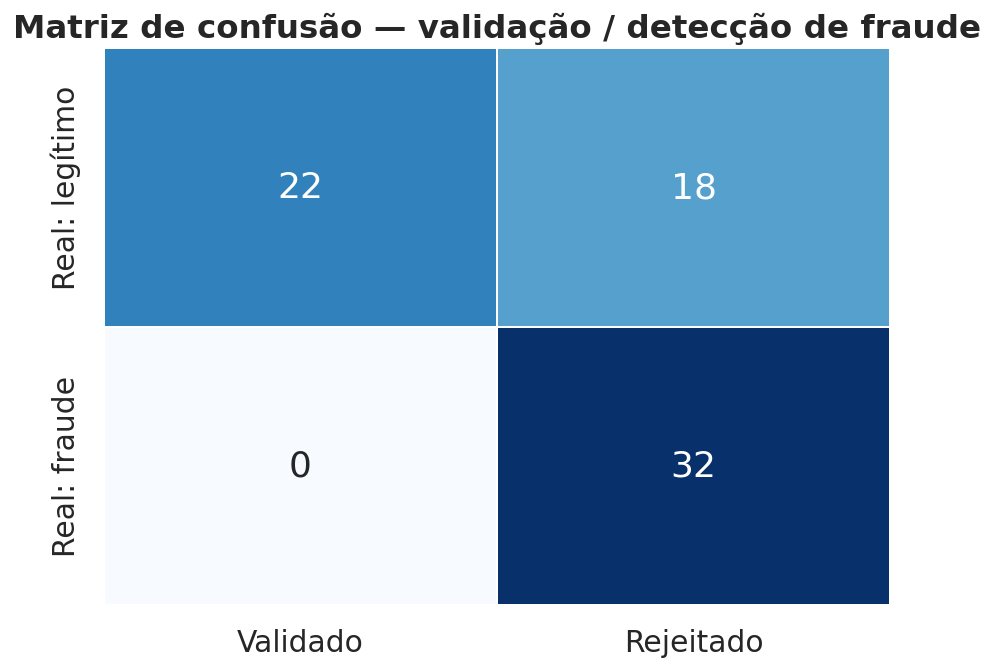

Acurácia    : 0.750
Precisão    : 0.640
Revocação   : 1.000  (sensibilidade a fraude)
Especificid.: 0.550
F1-score    : 0.780

Fraudes que passaram (FN): 0
Legítimos rejeitados (FP): 18  (ver seção 7 — dados reais problemáticos)


In [4]:
b = df[df["categoria"].isin(["legítimo", "agressivo", "fraude"])].copy()
b["rejeitado"] = ~b["validado"]

TP = int((b["is_fraude"] & b["rejeitado"]).sum())     # fraude corretamente rejeitada
FN = int((b["is_fraude"] & ~b["rejeitado"]).sum())    # fraude que passou
FP = int((~b["is_fraude"] & b["rejeitado"]).sum())    # legítimo rejeitado
TN = int((~b["is_fraude"] & ~b["rejeitado"]).sum())   # legítimo validado

acc  = (TP + TN) / (TP + TN + FP + FN)
prec = TP / (TP + FP) if (TP + FP) else float("nan")
rec  = TP / (TP + FN) if (TP + FN) else float("nan")
spec = TN / (TN + FP) if (TN + FP) else float("nan")
f1   = 2 * prec * rec / (prec + rec) if prec + rec else float("nan")

cm = pd.DataFrame([[TN, FP], [FN, TP]],
                  index=["Real: legítimo", "Real: fraude"],
                  columns=["Validado", "Rejeitado"])
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1,
            linecolor="white", annot_kws={"size": 20}, ax=ax)
ax.set_title("Matriz de confusão — validação / detecção de fraude")
fig.tight_layout(); fig.savefig(OUT / "matriz_confusao_validacao.png"); plt.show()

print(f"Acurácia    : {acc:.3f}")
print(f"Precisão    : {prec:.3f}")
print(f"Revocação   : {rec:.3f}  (sensibilidade a fraude)")
print(f"Especificid.: {spec:.3f}")
print(f"F1-score    : {f1:.3f}")
print(f"\nFraudes que passaram (FN): {FN}")
print(f"Legítimos rejeitados (FP): {FP}  (ver seção 7 — dados reais problemáticos)")


## 4. O detector correto disparou?

Cada cenário de fraude tem um detector físico esperado. Verifica-se se a anomalia
identificada corresponde ao tipo de fraude.


Cenário de fraude -> detector esperado vs. detectado:
                              scenario       exp_anomaly           anomaly  n
       06_fraude_velocidade_impossivel  impossible_speed  impossible_speed  8
07_fraude_motor_desligado_em_movimento engine_off_motion engine_off_motion  8
        08_fraude_bot_gerador_de_dados      robotic_data      robotic_data  8
 09_fraude_sensor_temperatura_hackeado  temperature_hack engine_off_motion  2
 09_fraude_sensor_temperatura_hackeado  temperature_hack  temperature_hack  6

Detector correto em 94% das fraudes (30/32)


C:\Users\FUNPEC\AppData\Local\Temp\ipykernel_25120\2444056892.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont.values, y=cont.index, ax=ax, palette="rocket")


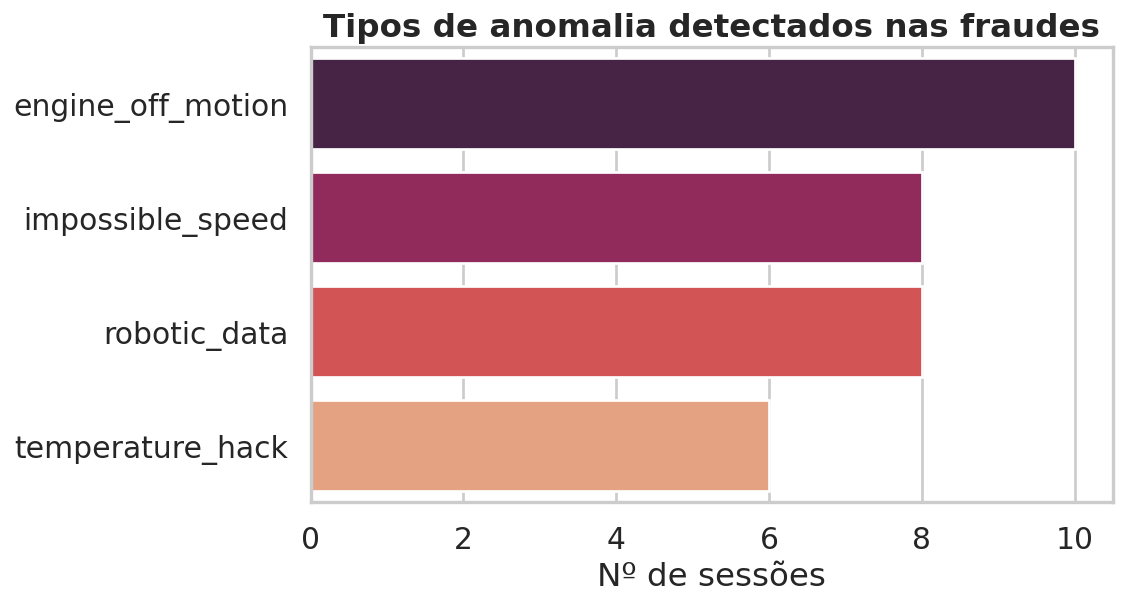

In [5]:
fr = df[df["categoria"] == "fraude"].copy()
fr["detector_correto"] = fr["anomaly"] == fr["exp_anomaly"]
tab = fr.groupby(["scenario", "exp_anomaly", "anomaly"]).size().reset_index(name="n")
print("Cenário de fraude -> detector esperado vs. detectado:")
print(tab.to_string(index=False))
print(f"\nDetector correto em {fr['detector_correto'].mean()*100:.0f}% das fraudes "
      f"({fr['detector_correto'].sum()}/{len(fr)})")

cont = fr["anomaly"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cont.values, y=cont.index, ax=ax, palette="rocket")
ax.set_xlabel("Nº de sessões"); ax.set_ylabel("")
ax.set_title("Tipos de anomalia detectados nas fraudes")
fig.tight_layout(); fig.savefig(OUT / "detectores_anomalia.png"); plt.show()


## 5. Emissão de crédito (governança)

O crédito deve ser emitido **se e somente se**: a sessão foi validada **E** emite
abaixo da baseline (175 gCO₂/km). Recalculamos a regra de forma independente e
comparamos com a decisão de governança registrada — deve haver 100% de consistência.

Importante: viagens legítimas que emitem **acima** da baseline corretamente **não**
recebem crédito. Isso não é erro — é o princípio do crédito de carbono.


Sessões válidas avaliadas: 72
Consistência regra recalculada vs. governança: 100.0%  (inconsistências: 0)

De 22 sessões validadas: 14 abaixo da baseline (com crédito), 8 acima (sem crédito — correto).


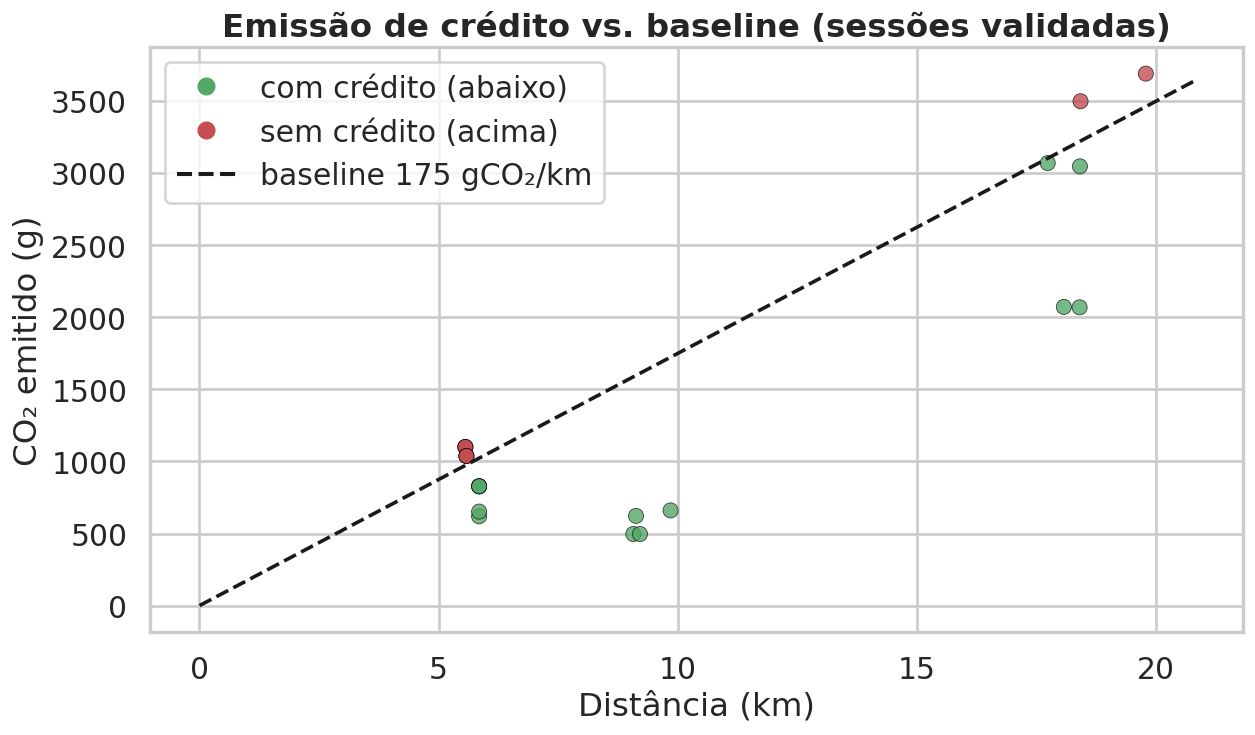

In [6]:
ok = df[df["status"] == "ok"].copy()
ok["gkm"] = np.where(ok["distance_km"] > 0, ok["co2_g"] / ok["distance_km"], np.nan)
# Regra esperada (recalculada): crédito sse validado E emite abaixo da baseline
ok["credito_esperado"] = ok["validado"] & (ok["co2_g"] < BASELINE_G_PER_KM * ok["distance_km"])
ok["consistente"] = ok["credito_esperado"] == ok["recebeu_credito"]

n_inconsist = int((~ok["consistente"]).sum())
print(f"Sessões válidas avaliadas: {len(ok)}")
print(f"Consistência regra recalculada vs. governança: "
      f"{100*ok['consistente'].mean():.1f}%  (inconsistências: {n_inconsist})")
if n_inconsist:
    print(ok[~ok["consistente"]][["vehicle","scenario","gkm","validado",
          "recebeu_credito","credito_esperado"]].to_string(index=False))

# Entre as VALIDADAS, separar quem recebeu crédito (abaixo da baseline) de quem não
val = ok[ok["validado"]]
abaixo = int((val["recebeu_credito"]).sum())
acima  = int((~val["recebeu_credito"]).sum())
print(f"\nDe {len(val)} sessões validadas: {abaixo} abaixo da baseline (com crédito), "
      f"{acima} acima (sem crédito — correto).")

fig, ax = plt.subplots(figsize=(10, 6))
colors = val["recebeu_credito"].map({True: "#55A868", False: "#C44E52"})
ax.scatter(val["distance_km"], val["co2_g"], c=colors, s=70, alpha=0.8,
           edgecolor="black", linewidth=0.4)
xs = np.linspace(0, val["distance_km"].max() * 1.05, 50)
ax.plot(xs, BASELINE_G_PER_KM * xs, "k--", lw=2,
        label=f"baseline {BASELINE_G_PER_KM:.0f} gCO₂/km")
ax.set_xlabel("Distância (km)"); ax.set_ylabel("CO₂ emitido (g)")
ax.set_title("Emissão de crédito vs. baseline (sessões validadas)")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#55A868", markersize=11, label="com crédito (abaixo)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#C44E52", markersize=11, label="sem crédito (acima)"),
    Line2D([0],[0], ls="--", color="k", label=f"baseline {BASELINE_G_PER_KM:.0f} gCO₂/km"),
])
fig.tight_layout(); fig.savefig(OUT / "emissao_credito_baseline.png"); plt.show()


## 6. Correção do valor dos créditos

Para toda sessão com crédito, o valor deve seguir `créditos_CCT = CO2_economizado_g / 1000`.


Sessões com crédito: 14
Erro máximo (emitido vs fórmula): 4.33e-06 CCT
Erro médio: 2.48e-06 CCT (apenas arredondamento)


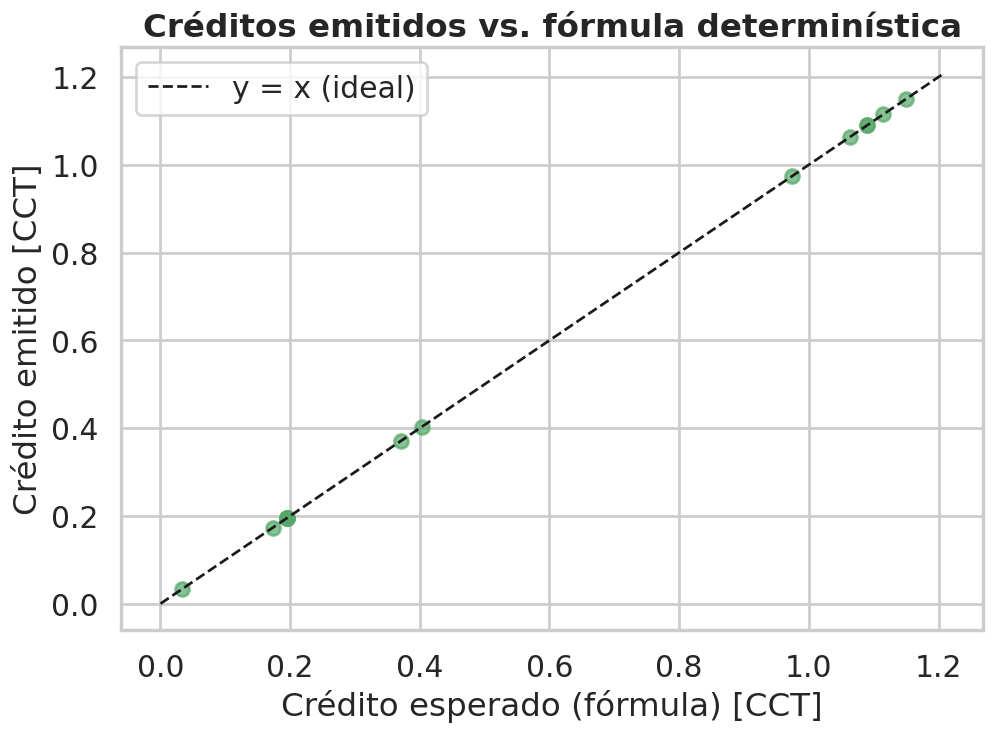

In [7]:
apr = df[df["recebeu_credito"]].dropna(subset=["credits_cct", "saved_g"]).copy()
if apr.empty:
    print("Nenhuma sessão recebeu crédito nesta rodada.")
else:
    apr["credito_formula"] = apr["saved_g"] / 1000.0
    apr["erro_abs"] = (apr["credits_cct"] - apr["credito_formula"]).abs()
    print(f"Sessões com crédito: {len(apr)}")
    print(f"Erro máximo (emitido vs fórmula): {apr['erro_abs'].max():.2e} CCT")
    print(f"Erro médio: {apr['erro_abs'].mean():.2e} CCT (apenas arredondamento)")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(apr["credito_formula"], apr["credits_cct"], s=60, alpha=0.7,
               color=sns.color_palette("deep")[2])
    lim = [0, apr["credito_formula"].max() * 1.05]
    ax.plot(lim, lim, "k--", lw=1.5, label="y = x (ideal)")
    ax.set_xlabel("Crédito esperado (fórmula) [CCT]")
    ax.set_ylabel("Crédito emitido [CCT]")
    ax.set_title("Créditos emitidos vs. fórmula determinística")
    ax.legend(); fig.tight_layout()
    fig.savefig(OUT / "creditos_corretos.png"); plt.show()


## 7. Casos legítimos rejeitados (falsos positivos da validação)

Análise honesta: alguns dados reais legítimos são rejeitados pelo validador.
Distingue-se o que é **acerto do oráculo sobre dado problemático** (CO2 zero,
movimento com motor desligado) do que seria falha de lógica.


In [8]:
fp = df[(df["categoria"].isin(["legítimo", "agressivo"])) & (~df["validado"]) & (df["status"] == "ok")]
if fp.empty:
    print("Nenhum legítimo rejeitado pelo validador.")
else:
    print(f"{len(fp)} sessões legítimas rejeitadas pelo validador:")
    print(fp[["vehicle", "viagem", "scenario", "co2_g", "anomaly"]].to_string(index=False))
    print("\nPor motivo:")
    print(fp["anomaly"].value_counts().to_string())
    print("\nInterpretação: rejeições corretas sobre dados fisicamente inconsistentes "
          "(CO2=0 por ausência de MAF/rpm; movimento com motor desligado), não falha de lógica.")


18 sessões legítimas rejeitadas pelo validador:
 vehicle viagem                       scenario  co2_g           anomaly
fastback      1             01_viagem_perfeita   0.00           too_low
fastback      1               02_eco_motorista   0.00           too_low
fastback      1               03_viagem_etanol   0.00           too_low
fastback      1 04_falha_sensor_maf_mas_valido   0.00           too_low
fastback      1         05_motorista_agressivo   0.00           too_low
fastback      2             01_viagem_perfeita   0.00           too_low
fastback      2               02_eco_motorista   0.00           too_low
fastback      2               03_viagem_etanol   0.00           too_low
fastback      2 04_falha_sensor_maf_mas_valido   0.00           too_low
fastback      2         05_motorista_agressivo   0.00           too_low
    polo      1             01_viagem_perfeita 992.36 engine_off_motion
    polo      1               02_eco_motorista 595.42 engine_off_motion
    polo      1 

## 8. Síntese da acertividade

In [9]:
val_legit = df[df["categoria"].isin(["legítimo", "agressivo"])]["validado"].sum()
n_legit = int(df["categoria"].isin(["legítimo", "agressivo"]).sum())
print("=" * 62)
print(f"SÍNTESE — ACERTIVIDADE (rodada de referência: {ref})")
print("=" * 62)
print("VALIDAÇÃO / DETECÇÃO DE FRAUDE")
print(f"  Fraudes detectadas (TP)  : {TP}/{TP+FN}  (revocação {rec:.2f})")
print(f"  Fraudes que passaram (FN): {FN}" + ("  -> nenhuma fraude passou" if FN == 0 else ""))
print(f"  Legítimos validados      : {val_legit}/{n_legit}")
print(f"  Legítimos rejeitados (FP): {FP}  (dados reais problemáticos, seção 7)")
print(f"  Detector correto p/ fraude: {fr['detector_correto'].mean()*100:.0f}%")
print("EMISSÃO DE CRÉDITO")
print(f"  Consistência regra/baseline: {100*ok['consistente'].mean():.1f}%")
print(f"  Validadas c/ crédito (<{BASELINE_G_PER_KM:.0f}): {abaixo}")
print(f"  Validadas s/ crédito (>={BASELINE_G_PER_KM:.0f}): {acima}  (correto)")
if not apr.empty:
    print(f"  Erro máx. no valor do crédito: {apr['erro_abs'].max():.1e} CCT")
print("\nArtefatos salvos em:", OUT.resolve())


SÍNTESE — ACERTIVIDADE (rodada de referência: rodada_unica)
VALIDAÇÃO / DETECÇÃO DE FRAUDE
  Fraudes detectadas (TP)  : 32/32  (revocação 1.00)
  Fraudes que passaram (FN): 0  -> nenhuma fraude passou
  Legítimos validados      : 22/40
  Legítimos rejeitados (FP): 18  (dados reais problemáticos, seção 7)
  Detector correto p/ fraude: 94%
EMISSÃO DE CRÉDITO
  Consistência regra/baseline: 100.0%
  Validadas c/ crédito (<175): 14
  Validadas s/ crédito (>=175): 8  (correto)
  Erro máx. no valor do crédito: 4.3e-06 CCT

Artefatos salvos em: C:\Users\FUNPEC\Documents\GitHub\carbon-mas-v2\results\analise_acertividade
